# Assignment 3 — Train Set EDA

항공편 지연 예측 과제의 train set 데이터에 대한 탐색적 데이터 분석(EDA).

분석 목표:
1. 데이터 구조와 결측치 파악
2. 타깃(`Delay`)의 분포와 라벨링 상태 (semi-supervised 여부) 확인
3. 수치형/시간형/범주형 변수의 분포 점검
4. 라벨된 일부 데이터에서 그룹별 지연율(class rate) 비교
5. 후속 전처리·모델링에 필요한 인사이트 도출

> **규칙**
> - 하드코딩 금지: 데이터 경로·컬럼명·타깃명은 변수로 정의해 노트북 상단에서만 변경.
> - Train set만 사용 (`Delay` 미라벨 다수 → 준지도 학습 여지).


## 1. 환경 설정 및 데이터 로드

In [1]:
# >>> [분석 노트]
# 라이브러리 로드 및 표시 옵션 설정.
# - pandas/numpy: 데이터 처리
# - matplotlib/seaborn: 시각화
# - warnings 억제, 컬럼/너비 옵션으로 print 잘림 방지
# <<<
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")


In [2]:
# >>> [분석 노트]
# 데이터 위치·파일명·타깃명을 모두 변수화 (하드코딩 금지).
# - DATA_DIR: 환경변수 ASSIGNMENT3_DATA_DIR > ./data > ../data > . 순으로 탐색
# - TRAIN/TEST_FILENAME: 기본 train_set.csv / test_set.csv, 환경변수로 오버라이드 가능
# - resolve_csv: 정확 매칭 우선, 없으면 키워드 매칭으로 폴백
# <<<
# ----- 하드코딩 금지: 경로/파일명/컬럼을 모두 변수로 정의 -----
# 데이터 디렉터리: 환경변수 ASSIGNMENT3_DATA_DIR > ./data > ../data > .
def resolve_data_dir() -> Path:
    env = os.environ.get("ASSIGNMENT3_DATA_DIR")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd()
    for cand in [here / "data", here.parent / "data", here]:
        if cand.exists():
            return cand.resolve()
    return here.resolve()


def resolve_csv(data_dir: Path, exact: str, keyword: str) -> Path:
    """우선 정확한 파일명을 찾고, 없으면 키워드 매칭으로 폴백."""
    direct = data_dir / exact
    if direct.exists():
        return direct.resolve()
    matches = sorted(p for p in data_dir.glob("*.csv") if keyword.lower() in p.name.lower())
    if not matches:
        raise FileNotFoundError(
            f"Could not find {exact!r} or any csv containing {keyword!r} under {data_dir}"
        )
    return matches[0].resolve()


DATA_DIR = resolve_data_dir()

# 과제에서 제공된 실제 파일명 (환경변수로 오버라이드 가능)
TRAIN_FILENAME = os.environ.get("ASSIGNMENT3_TRAIN", "train_set.csv")
TEST_FILENAME  = os.environ.get("ASSIGNMENT3_TEST",  "test_set.csv")

TRAIN_PATH = resolve_csv(DATA_DIR, TRAIN_FILENAME, "train")
TEST_PATH  = resolve_csv(DATA_DIR, TEST_FILENAME,  "test")

ID_COL = "ID"
TARGET_COL = "Delay"
POSITIVE_LABEL = "Delayed"
NEGATIVE_LABEL = "Not_Delayed"

print("DATA_DIR :", DATA_DIR)
print("TRAIN    :", TRAIN_PATH.name)
print("TEST     :", TEST_PATH.name)


DATA_DIR : /tmp/data_zip
TRAIN    : train_set.csv
TEST     : test_set.csv


In [3]:
# >>> [분석 노트]
# train/test 로드 후 shape 확인 + 첫 5행 미리보기.
# - 컬럼 구성·타깃 위치·값 형태 파악이 목적
# <<<
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print(f"train shape: {train.shape}")
print(f"test  shape: {test.shape}")
train.head()


train shape: (800000, 19)
test  shape: (50936, 18)


,ID,Month,Day_of_Month,Estimated_Departure_Time,Estimated_Arrival_Time,Cancelled,Diverted,Origin_Airport,Origin_Airport_ID,Origin_State,Destination_Airport,Destination_Airport_ID,Destination_State,Distance,Airline,Carrier_Code(IATA),Carrier_ID(DOT),Tail_Number,Delay
0,TRAIN_000001,9,9,1145.0,1316.0,0,0,SEA,14747,Washington,MFR,13264,Oregon,352.0,Horizon Air,AS,19687.0,N430QX,NaN
1,TRAIN_000002,4,10,825.0,1005.0,0,0,DEN,11292,Colorado,OAK,13796,California,957.0,Southwest Airlines Co.,WN,19393.0,N216WR,NaN
2,TRAIN_000003,10,19,954.0,1158.0,0,0,CLT,11057,North Carolina,ALB,10257,New York,646.0,NaN,AA,19805.0,N881NN,NaN
3,TRAIN_000004,4,29,1920.0,2247.0,0,0,EWR,11618,New Jersey,SJC,14831,NaN,2548.0,United Air Lines Inc.,UA,19977.0,N76288,NaN
4,TRAIN_000005,5,26,635.0,1100.0,0,0,PHX,14107,Arizona,HOU,12191,Texas,1020.0,Southwest Airlines Co.,WN,19393.0,N730SW,NaN


## 2. 스키마 / dtypes / 결측치

In [4]:
# >>> [분석 노트]
# 스키마 한눈 요약: dtype / 고유값 수 / 결측 수 / 결측 비율.
# - 결측 비율 내림차순 정렬 → 어떤 변수가 가장 비어 있는지 우선 확인
# <<<
schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(dropna=True),
    "n_missing": train.isna().sum(),
    "missing_ratio": (train.isna().mean() * 100).round(2),
})
schema.sort_values("missing_ratio", ascending=False)


,dtype,n_unique,n_missing,missing_ratio
Delay,str,2,595935,74.49
Destination_State,str,52,87444,10.93
Carrier_ID(DOT),float64,28,87378,10.92
Airline,str,28,87301,10.91
Origin_State,str,52,87207,10.90
Carrier_Code(IATA),str,11,87112,10.89
Estimated_Arrival_Time,float64,1422,87143,10.89
Estimated_Departure_Time,float64,1361,87077,10.88
Day_of_Month,int64,31,0,0.00
ID,str,800000,0,0.00


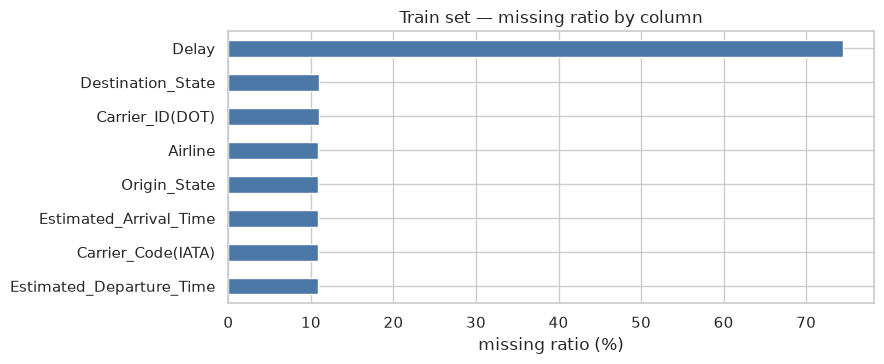

In [5]:
# >>> [분석 노트]
# 결측 비율 막대그래프 시각화 (수치 표 보강).
# - 0% 결측 컬럼은 그래프에서 제외해 의미있는 변수만 표시
# <<<
# 결측치 막대 시각화
miss = train.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if not miss.empty:
    fig, ax = plt.subplots(figsize=(9, 0.35 * len(miss) + 1))
    miss.mul(100).plot(kind="barh", ax=ax, color="#4C78A8")
    ax.invert_yaxis()
    ax.set_xlabel("missing ratio (%)")
    ax.set_title("Train set — missing ratio by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values.")


### 관찰
- `Delay` (타깃) 의 결측이 매우 크다 → **다수가 미라벨**. 준지도 학습 여지.
- `Estimated_Departure_Time`, `Estimated_Arrival_Time` 등 일부 입력 변수도 결측이 존재.
- 같은 카테고리 (Airline / Carrier_Code / Origin_State / Destination_State) 가 동시에 결측인 경우가 있는지 확인할 가치 있음.


In [6]:
# >>> [분석 노트]
# 주요 입력 변수들의 '동시 결측' 상관관계 점검.
# - 한 행에서 여러 컬럼이 함께 결측되는 패턴이 있는지 확인
# - 상관이 약하면 결측 메커니즘이 독립적(MCAR/MAR 단서)
# <<<
# 입력 변수들의 동시 결측 패턴 — 카테고리 결측이 같은 row 에 몰리는지 확인.
cat_cols_to_check = [c for c in
                     ["Origin_State", "Destination_State", "Airline",
                      "Carrier_Code(IATA)", "Carrier_ID(DOT)",
                      "Estimated_Departure_Time", "Estimated_Arrival_Time"]
                     if c in train.columns]
co_miss = train[cat_cols_to_check].isna().astype(int)
print("동시 결측 상관:")
print(co_miss.corr().round(2))


동시 결측 상관:


                          Origin_State  Destination_State  Airline  Carrier_Code(IATA)  Carrier_ID(DOT)  Estimated_Departure_Time  Estimated_Arrival_Time
Origin_State                       1.0                0.0     -0.0                 0.0             -0.0                      -0.0                     0.0
Destination_State                  0.0                1.0      0.0                -0.0              0.0                      -0.0                    -0.0
Airline                           -0.0                0.0      1.0                -0.0              0.0                      -0.0                    -0.0
Carrier_Code(IATA)                 0.0               -0.0     -0.0                 1.0              0.0                      -0.0                    -0.0
Carrier_ID(DOT)                   -0.0                0.0      0.0                 0.0              1.0                       0.0                     0.0
Estimated_Departure_Time          -0.0               -0.0     -0.0          

## 3. 타깃 `Delay` 분포 (semi-supervised 확인)

In [7]:
# >>> [분석 노트]
# 타깃(Delay) 값 분포 카운트 (NaN 포함).
# - 라벨링된 비율과 클래스 비율을 동시에 확인
# - 다수 NaN → semi-supervised 단서
# <<<
target_counts = train[TARGET_COL].value_counts(dropna=False)
print(target_counts)
print("\n라벨링 비율:")
print((target_counts / len(train) * 100).round(2).astype(str) + " %")


Delay
NaN            595935
Not_Delayed    168010
Delayed         36055
Name: count, dtype: int64

라벨링 비율:
Delay
NaN            74.49 %
Not_Delayed     21.0 %
Delayed         4.51 %
Name: count, dtype: str


labeled rows  : 204,065 (25.51% of train)
unlabeled rows: 595,935

클래스 분포 (labeled 기준):
Delay
Not_Delayed    0.8233
Delayed        0.1767
Name: proportion, dtype: float64


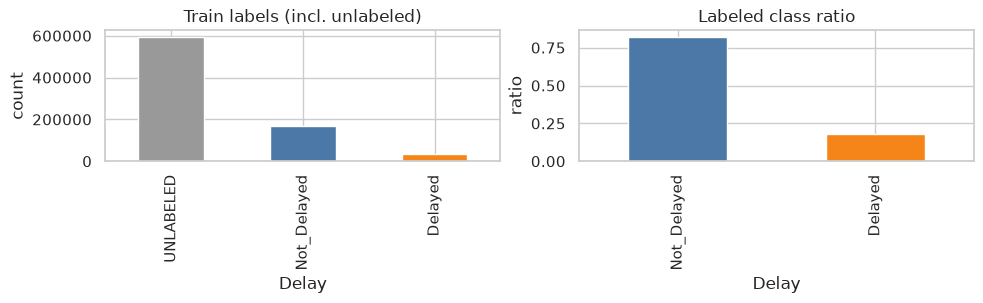

In [8]:
# >>> [분석 노트]
# 라벨된 행만 추출해 클래스 불균형 점검.
# - 시각화 2분할: 전체(미라벨 포함) vs 라벨 클래스 비율
# - 후속 모델링에서 class_weight / 임계값 조정 고려에 사용
# <<<
# 라벨된 데이터만 추출 — 클래스 불균형 확인
labeled = train.dropna(subset=[TARGET_COL]).copy()
print(f"labeled rows  : {len(labeled):,} ({len(labeled)/len(train)*100:.2f}% of train)")
print(f"unlabeled rows: {train[TARGET_COL].isna().sum():,}")

class_dist = labeled[TARGET_COL].value_counts(normalize=True).round(4)
print("\n클래스 분포 (labeled 기준):")
print(class_dist)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
train[TARGET_COL].fillna("UNLABELED").value_counts().plot(
    kind="bar", ax=ax[0], color=["#999", "#4C78A8", "#F58518"])
ax[0].set_title("Train labels (incl. unlabeled)")
ax[0].set_ylabel("count")

class_dist.plot(kind="bar", ax=ax[1], color=["#4C78A8", "#F58518"])
ax[1].set_title("Labeled class ratio")
ax[1].set_ylabel("ratio")
plt.tight_layout(); plt.show()


### 관찰
- 라벨이 있는 행은 train 전체의 일부에 불과 → 다수가 미라벨.
- 라벨된 데이터 안에서도 클래스 불균형(`Not_Delayed` ≫ `Delayed`) 존재 → 학습 시 class_weight / SMOTE / threshold tuning 고려.


## 4. 시간 변수 처리 (`HH:MM` → 분 단위)

In [9]:
# >>> [분석 노트]
# 전처리: HH:MM(예 1316.0) → 분 단위 정수.
# - 잘못된 시각(>23시 / >59분)은 NaN 처리해 노이즈 제거
# - TIME_COLS 에 대해 *_min 파생 컬럼 생성
# <<<
def hhmm_to_minutes(x):
    """1316.0 → 13:16 → 13*60+16. NaN 은 그대로 NaN."""
    if pd.isna(x):
        return np.nan
    v = int(x)
    h, m = divmod(v, 100)
    if not (0 <= h <= 23 and 0 <= m <= 59):
        return np.nan
    return h * 60 + m


TIME_COLS = ["Estimated_Departure_Time", "Estimated_Arrival_Time"]
for c in TIME_COLS:
    if c in train.columns:
        train[c + "_min"] = train[c].apply(hhmm_to_minutes)

train[[*TIME_COLS, *(c + "_min" for c in TIME_COLS)]].head()


,Estimated_Departure_Time,Estimated_Arrival_Time,Estimated_Departure_Time_min,Estimated_Arrival_Time_min
0,1145.0,1316.0,705.0,796.0
1,825.0,1005.0,505.0,605.0
2,954.0,1158.0,594.0,718.0
3,1920.0,2247.0,1160.0,1367.0
4,635.0,1100.0,395.0,660.0


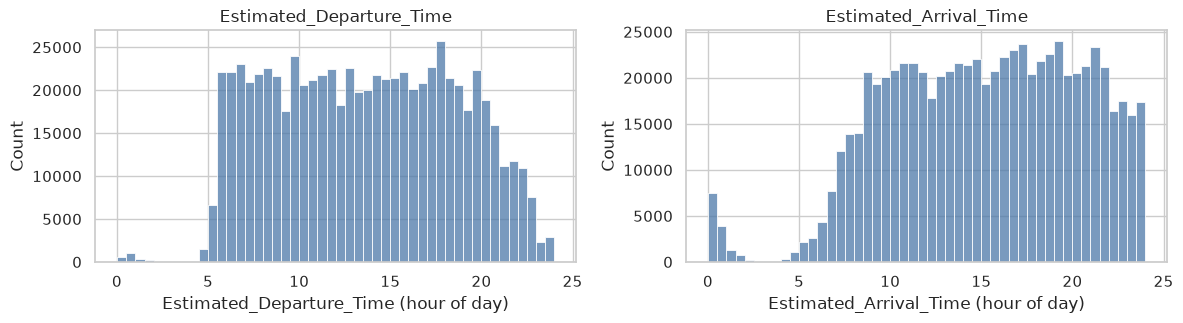

In [10]:
# >>> [분석 노트]
# 출발/도착 시간을 hour 단위 히스토그램으로 시각화.
# - 운항 피크 시간대(이른 아침~저녁) 분포 파악
# <<<
# 출/도착 시각 분포 (시간대별)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, c in zip(axes, TIME_COLS):
    col = c + "_min"
    s = train[col].dropna() / 60  # 시간 단위
    sns.histplot(s, bins=48, ax=ax, color="#4C78A8")
    ax.set_xlabel(f"{c} (hour of day)")
    ax.set_title(c)
plt.tight_layout(); plt.show()


In [11]:
# >>> [분석 노트]
# 비행 소요시간(분) 파생: 도착 - 출발.
# - 음수(자정 넘김) 보정: +24h
# - 후속 모델 피처 후보로 사용
# <<<
# 비행시간 추정 (도착 - 출발) — overnight 보정
dep = train["Estimated_Departure_Time_min"]
arr = train["Estimated_Arrival_Time_min"]
duration = arr - dep
duration = duration.where(duration >= 0, duration + 24 * 60)  # 자정 넘김
train["Estimated_Duration_min"] = duration

duration.describe()


count    635141.000000
mean        140.705084
std         101.650459
min           0.000000
25%          80.000000
50%         113.000000
75%         170.000000
max        1439.000000
dtype: float64

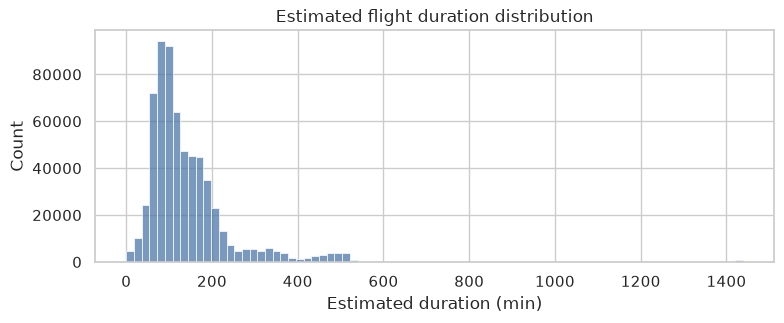

In [12]:
# >>> [분석 노트]
# 비행 소요시간 분포 시각화.
# - 단거리/장거리 비행 비율, 이상치 존재 여부 파악
# <<<
fig, ax = plt.subplots(figsize=(8, 3.4))
sns.histplot(duration.dropna(), bins=80, ax=ax, color="#4C78A8")
ax.set_xlabel("Estimated duration (min)")
ax.set_title("Estimated flight duration distribution")
plt.tight_layout(); plt.show()


## 5. 수치형 변수 분포

In [13]:
# >>> [분석 노트]
# 수치형 변수 일괄 기술통계 (describe).
# - Month/Day/Distance/시간 파생 변수의 평균·분산·범위 확인
# <<<
NUMERIC_COLS = [c for c in
                ["Month", "Day_of_Month", "Distance",
                 "Estimated_Departure_Time_min",
                 "Estimated_Arrival_Time_min",
                 "Estimated_Duration_min"]
                if c in train.columns]
train[NUMERIC_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
Month,800000.0,6.946174,3.463210,1.0,4.0,7.0,10.0,12.0
Day_of_Month,800000.0,15.768371,8.765089,1.0,8.0,16.0,23.0,31.0
Distance,800000.0,784.531430,590.663400,16.0,351.0,623.0,1020.0,5095.0
Estimated_Departure_Time_min,712923.0,815.562287,294.679063,1.0,565.0,813.0,1062.0,1439.0
Estimated_Arrival_Time_min,712847.0,907.725951,312.711419,1.0,665.0,924.0,1164.0,1439.0
Estimated_Duration_min,635141.0,140.705084,101.650459,0.0,80.0,113.0,170.0,1439.0


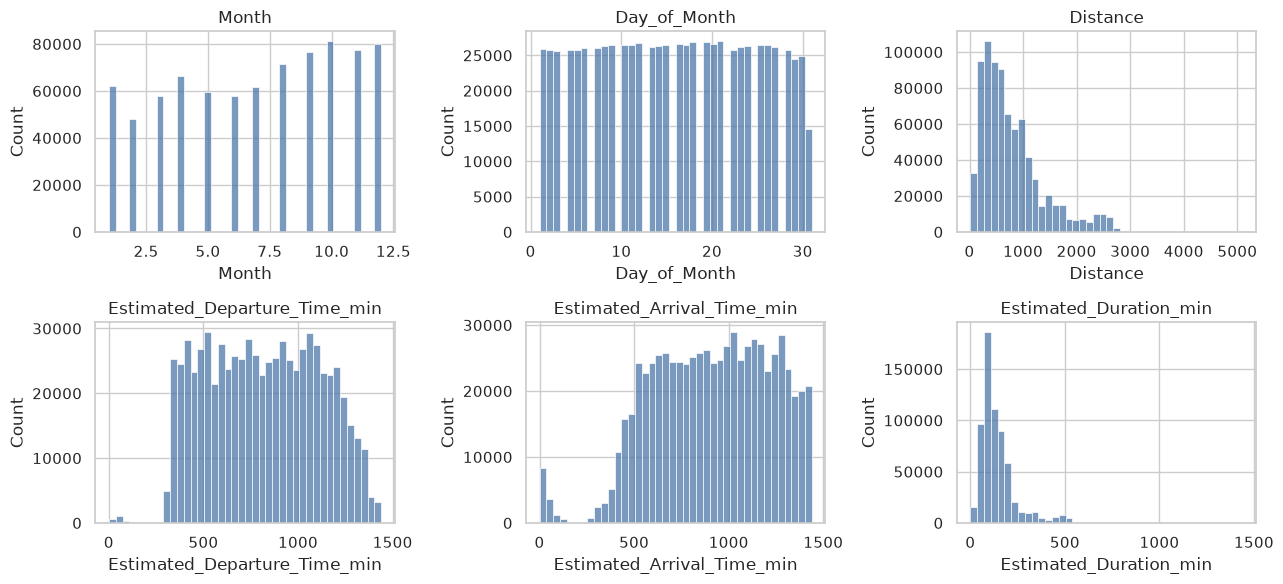

In [14]:
# >>> [분석 노트]
# 수치형 변수 히스토그램 6개를 격자 배치.
# - skew/특이 분포/이상치 후보 점검
# <<<
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.flatten(), NUMERIC_COLS):
    sns.histplot(train[c].dropna(), bins=40, ax=ax, color="#4C78A8")
    ax.set_title(c)
plt.tight_layout(); plt.show()


In [15]:
# >>> [분석 노트]
# 이진 변수(Cancelled/Diverted) 값 카운트.
# - 분포가 한쪽으로 극단적으로 쏠리는지 확인 → 모델 피처로 유의한지 판단
# <<<
# 이진/저카디널리티 변수
for c in ["Cancelled", "Diverted"]:
    if c in train.columns:
        print(f"{c}:")
        print(train[c].value_counts(dropna=False))
        print()


Cancelled:
Cancelled
0    800000
Name: count, dtype: int64

Diverted:
Diverted
0    800000
Name: count, dtype: int64



## 6. 범주형 변수 카디널리티

In [16]:
# >>> [분석 노트]
# 범주형 변수 카디널리티 요약 (고유값/결측).
# - 고카디널리티(Tail_Number) 변수는 target/frequency encoding 후보
# - 저카디널리티(주/항공사)는 one-hot 가능
# <<<
CAT_CANDIDATES = ["Origin_Airport", "Origin_Airport_ID", "Origin_State",
                  "Destination_Airport", "Destination_Airport_ID", "Destination_State",
                  "Airline", "Carrier_Code(IATA)", "Carrier_ID(DOT)", "Tail_Number"]
CAT_CANDIDATES = [c for c in CAT_CANDIDATES if c in train.columns]

cat_summary = pd.DataFrame({
    "n_unique": [train[c].nunique(dropna=True) for c in CAT_CANDIDATES],
    "n_missing": [train[c].isna().sum() for c in CAT_CANDIDATES],
}, index=CAT_CANDIDATES).sort_values("n_unique", ascending=False)
cat_summary


,n_unique,n_missing
Tail_Number,6422,0
Destination_Airport,375,0
Destination_Airport_ID,375,0
Origin_Airport,374,0
Origin_Airport_ID,374,0
Origin_State,52,87207
Destination_State,52,87444
Airline,28,87301
Carrier_ID(DOT),28,87378
Carrier_Code(IATA),11,87112


### 관찰
- `Tail_Number` 카디널리티가 매우 높음 → high-cardinality 처리 필요 (target encoding 등).
- `Origin_State` / `Destination_State` 는 50 미만으로 일반 one-hot 가능.
- `Airline` ↔ `Carrier_Code(IATA)` ↔ `Carrier_ID(DOT)` 간 중복성 존재 가능 → 다음 셀에서 점검.


In [17]:
# >>> [분석 노트]
# 항공사 식별자 간 중복성 점검 (Airline/Carrier_Code/Carrier_ID).
# - 단일매핑 비율이 100%에 가까우면 두 컬럼이 사실상 같은 정보 → 하나만 사용
# <<<
# 항공사 식별자 간 중복성 — 한 그룹에 매핑이 1:1 인지 확인
def check_one_to_one(df, a, b):
    g = df.dropna(subset=[a, b]).groupby(a)[b].nunique()
    return (g == 1).mean(), int(g.gt(1).sum())

for a, b in [("Airline", "Carrier_Code(IATA)"),
             ("Airline", "Carrier_ID(DOT)"),
             ("Carrier_Code(IATA)", "Carrier_ID(DOT)")]:
    if a in train.columns and b in train.columns:
        ratio, n_multi = check_one_to_one(train, a, b)
        print(f"{a} → {b}: 단일매핑 비율 {ratio*100:.2f}% / 다중매핑 그룹 수 {n_multi}")


Airline → Carrier_Code(IATA): 단일매핑 비율 75.00% / 다중매핑 그룹 수 7
Airline → Carrier_ID(DOT): 단일매핑 비율 100.00% / 다중매핑 그룹 수 0


Carrier_Code(IATA) → Carrier_ID(DOT): 단일매핑 비율 54.55% / 다중매핑 그룹 수 5


## 7. 라벨된 데이터에서 그룹별 지연율

In [18]:
# >>> [분석 노트]
# 타깃을 이진 정수(0/1)로 변환 + 전체 base rate 산출.
# - 이후 그룹별 지연율을 base rate 와 비교하는 기준선
# <<<
labeled = labeled.copy()
labeled["is_delayed"] = (labeled[TARGET_COL] == POSITIVE_LABEL).astype(int)
print("전체 base rate(Delayed):", labeled["is_delayed"].mean().round(4))


전체 base rate(Delayed): 0.1767


In [19]:
# >>> [분석 노트]
# 그룹별 지연율 + 표본 수 산출 함수.
# - min_count 로 표본 부족 그룹은 제외해 통계 노이즈 억제
# - Month / Airline / Origin_State / Destination_State 별 비교
# <<<
def rate_by(col, top=15, min_count=200):
    g = labeled.groupby(col)["is_delayed"].agg(["mean", "count"])
    g = g[g["count"] >= min_count].sort_values("mean", ascending=False)
    return g.head(top)


for col in ["Month", "Airline", "Origin_State", "Destination_State"]:
    if col in labeled.columns:
        print(f"\n=== {col} ===")
        print(rate_by(col))



=== Month ===
           mean  count
Month                 
6      0.223356  14018
7      0.206252  15515
2      0.204490  11805
8      0.198912  17646
5      0.191537  15219
12     0.181938  20463
1      0.170022  15845
3      0.168601  14994
4      0.163649  17122
11     0.159477  20122
10     0.145535  21232
9      0.141356  20084

=== Airline ===
                                               mean  count
Airline                                                   
Commutair Aka Champlain Enterprises, Inc.  0.290525   1277
Frontier Airlines Inc.                     0.261072   3432
JetBlue Airways                            0.243989   8152
Trans States Airlines                      0.223473   1866
Allegiant Air                              0.194668   2738
ExpressJet Airlines Inc.                   0.191574   4035
Southwest Airlines Co.                     0.188516  37042
American Airlines Inc.                     0.187857  16651
United Air Lines Inc.                      0.182446  170

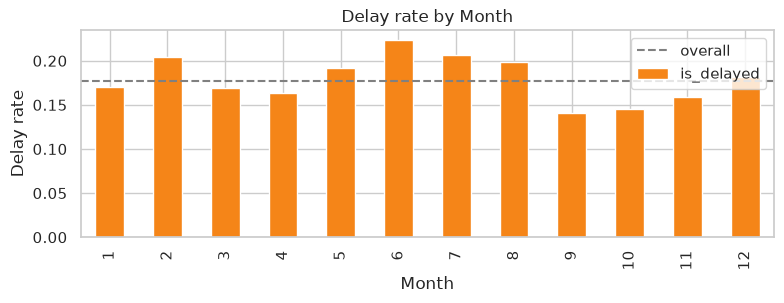

In [20]:
# >>> [분석 노트]
# 월(Month)별 지연율 시각화.
# - 여름철(6~8월) 등 계절성 지연 여부 확인
# <<<
# 시각화: Month × delay rate
if "Month" in labeled.columns:
    monthly = labeled.groupby("Month")["is_delayed"].mean()
    fig, ax = plt.subplots(figsize=(8, 3.2))
    monthly.plot(kind="bar", ax=ax, color="#F58518")
    ax.axhline(labeled["is_delayed"].mean(), color="gray", linestyle="--", label="overall")
    ax.set_ylabel("Delay rate"); ax.set_title("Delay rate by Month")
    ax.legend()
    plt.tight_layout(); plt.show()


In [21]:
# >>> [분석 노트]
# 출발 시간대(hour)별 지연율 시각화.
# - 늦은 시간대일수록 지연이 누적되는 경향(영향) 점검
# <<<
# 출발 시간대(hour) 별 지연율
if "Estimated_Departure_Time_min" in labeled.columns:
    dep_hour = (labeled["Estimated_Departure_Time_min"] // 60).astype("Int64")
    tmp = pd.DataFrame({"dep_hour": dep_hour, "y": labeled["is_delayed"]}).dropna()
    h_rate = tmp.groupby("dep_hour")["y"].mean()
    fig, ax = plt.subplots(figsize=(9, 3.2))
    h_rate.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.axhline(labeled["is_delayed"].mean(), color="gray", linestyle="--", label="overall")
    ax.set_ylabel("Delay rate"); ax.set_title("Delay rate by departure hour")
    ax.legend()
    plt.tight_layout(); plt.show()


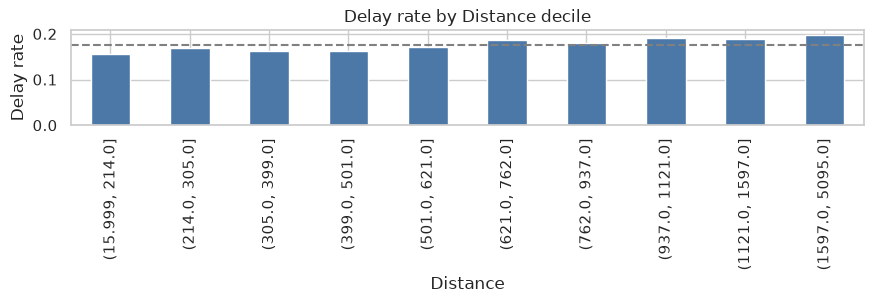

In [22]:
# >>> [분석 노트]
# Distance 를 10분위로 비닝해 구간별 지연율 시각화.
# - 거리와 지연율의 단조 관계 여부 확인 (단거리/장거리 영향)
# <<<
# Distance 구간별 지연율 (quantile binning)
if "Distance" in labeled.columns:
    bins = pd.qcut(labeled["Distance"], q=10, duplicates="drop")
    g = labeled.groupby(bins)["is_delayed"].mean()
    fig, ax = plt.subplots(figsize=(9, 3.2))
    g.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.axhline(labeled["is_delayed"].mean(), color="gray", linestyle="--")
    ax.set_ylabel("Delay rate")
    ax.set_title("Delay rate by Distance decile")
    plt.tight_layout(); plt.show()


## 8. 수치형 변수 상관관계

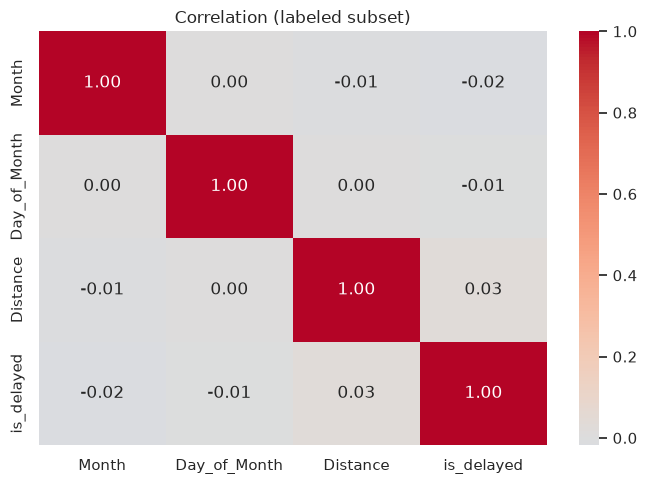

In [23]:
# >>> [분석 노트]
# 수치형 변수 + is_delayed 간 상관관계 히트맵.
# - 강한 상관 변수 식별 → 다중공선성 / 피처 후보 판단
# <<<
num_for_corr = [c for c in NUMERIC_COLS if c in labeled.columns] + ["is_delayed"]
corr = labeled[num_for_corr].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation (labeled subset)")
plt.tight_layout(); plt.show()


## 9. Cancelled / Diverted vs Delay

In [24]:
# >>> [분석 노트]
# Cancelled/Diverted × Delay 교차표(행 정규화).
# - 두 이진 변수가 라벨된 데이터에 변동을 주는지 확인
# <<<
for c in ["Cancelled", "Diverted"]:
    if c in labeled.columns:
        ct = pd.crosstab(labeled[c], labeled[TARGET_COL], normalize="index").round(4)
        print(f"\n{c} 별 클래스 분포:")
        print(ct)



Cancelled 별 클래스 분포:
Delay      Delayed  Not_Delayed
Cancelled                      
0           0.1767       0.8233

Diverted 별 클래스 분포:
Delay     Delayed  Not_Delayed
Diverted                      
0          0.1767       0.8233


## 10. 결측치 자체가 가지는 신호 여부

In [25]:
# >>> [분석 노트]
# 각 입력 변수의 결측 여부가 타깃에 신호를 주는지 비교.
# - 결측 그룹 vs 비결측 그룹의 지연율 차이 Δ 산출
# - Δ 가 크면 *_is_missing 플래그를 피처로 사용 가치 있음
# <<<
# 입력 변수의 결측 여부가 Delay와 관계있는지 확인
for c in ["Estimated_Departure_Time", "Estimated_Arrival_Time",
          "Airline", "Carrier_Code(IATA)", "Origin_State", "Destination_State"]:
    if c in labeled.columns:
        miss_flag = labeled[c].isna()
        rate_missing = labeled.loc[miss_flag, "is_delayed"].mean()
        rate_present = labeled.loc[~miss_flag, "is_delayed"].mean()
        diff = (rate_missing - rate_present) if not np.isnan(rate_missing) else float("nan")
        print(f"{c:34s}  missing→delay={rate_missing if not np.isnan(rate_missing) else 'NA':>8} "
              f"present→delay={rate_present:>.4f}  Δ={diff if not np.isnan(diff) else 'NA'}")


Estimated_Departure_Time            missing→delay=0.17533875338753388 present→delay=0.1768  Δ=-0.0015088486462712658
Estimated_Arrival_Time              missing→delay=0.17874898309680917 present→delay=0.1764  Δ=0.002316222666115364
Airline                             missing→delay=0.1758670782640276 present→delay=0.1768  Δ=-0.0009156637060114825
Carrier_Code(IATA)                  missing→delay=0.18173253779552287 present→delay=0.1761  Δ=0.005667754053073459
Origin_State                        missing→delay=0.17641509433962263 present→delay=0.1767  Δ=-0.00030171762924510737
Destination_State                   missing→delay=0.17669445451250454 present→delay=0.1767  Δ=1.1834851308789585e-05


## 11. 요약 및 후속 단계 제안

### 데이터 특성
- 19개 컬럼, 약 80만 행. ID 와 타깃 외 17개 입력 변수.
- **타깃(`Delay`) 의 다수(약 74%)가 미라벨** → 준지도 학습 활용 여지.
- 라벨된 데이터 안에서 클래스 비율은 `Not_Delayed` 약 82% / `Delayed` 약 18% — **불균형**.
- 일부 카테고리(`Airline`, `Carrier_Code(IATA)`, `Carrier_ID(DOT)`, `Origin_State`, `Destination_State`)와 시각 변수(`Estimated_*_Time`)에 결측이 존재. 동시 결측 경향이 있을 수 있음.
- `Tail_Number` 는 카디널리티가 매우 높아 직접 one-hot 부적절.

### 전처리 제안
1. 시각(`HH:MM`) → 분 단위 변환 + 출/도착 hour 별 파생.
2. `Estimated_Duration_min` 등 시간차 파생 변수 추가.
3. 결측 자체를 신호로 보존 (`*_is_missing` 플래그).
4. 고카디널리티 범주(`Tail_Number`) 는 frequency / target encoding.
5. 항공사 식별자 중 중복성 높은 것은 하나만 사용하고 나머지는 보조 피처.
6. 클래스 불균형 대응: `class_weight`, `scale_pos_weight`, 또는 stratified sampling.

### 모델링 제안
- **Cross validation 필수** (과제 명시) — Stratified K-Fold.
- 베이스라인: Logistic Regression, RandomForest.
- 메인: Gradient Boosted Trees (LightGBM / XGBoost / CatBoost) — 결측·고카디널리티에 강함.
- 준지도 학습: pseudo-labeling, self-training.
- 평가 지표는 채점 기준인 **Log-loss**.
